# Futures Price Prediction Model - MVE with SNNs

This notebook runs the futures price prediction model interactively.


## Setup and Imports


In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from typing import Tuple, Optional
from datetime import datetime

# Add the current directory to path for imports
notebook_dir = os.path.dirname(os.path.abspath('__file__' if '__file__' in globals() else '.'))
if notebook_dir not in sys.path:
    sys.path.insert(0, notebook_dir)

# Import from the Python script
from futures_ploting_utils import plot_results

# Import classes and functions from the main script
# We'll import them directly by executing the script content or importing the module
import importlib.util
spec = importlib.util.spec_from_file_location("futures_model", "futures_model_MVE_SSNs.py")
if spec is None or spec.loader is None:
    raise ImportError("Could not load futures_model_MVE_SSNs.py")
futures_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(futures_module)

# Extract classes and functions
FuturesDataset = futures_module.FuturesDataset
MVEModel = futures_module.MVEModel
negative_log_likelihood_loss = futures_module.negative_log_likelihood_loss
mse_loss = futures_module.mse_loss
prepare_data = futures_module.prepare_data
train_model = futures_module.train_model
evaluate_model = futures_module.evaluate_model
save_training_results = futures_module.save_training_results

print("All imports successful!")


All imports successful!


## Configuration


In [ ]:
# Configuration
# Get the directory - in Jupyter, os.getcwd() should be the notebook's directory
NOTEBOOK_DIR = os.getcwd()

DATA_PATH = os.path.join(NOTEBOOK_DIR, 'es_with_indicators.csv')
# Alternative: if running from notebook directory
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'es_with_indicators.csv'

TARGET_COL = 'PctChange_ToMaxHigh_5'
BATCH_SIZE = 128
NUM_EPOCHS = 100
LEARNING_RATE = 0.01
OPTIMIZE_MEAN_ONLY_STEPS = 0
HIDDEN_DIMS = [128, 2]
Golden_Test = True  # Set to False for full training

# Output paths (use the same directory as notebook)
PLOT_PATH = os.path.join(NOTEBOOK_DIR, 'future_model_MVE_SSNs_results.png')
MODEL_PATH = os.path.join(NOTEBOOK_DIR, 'futures_model.pt')
RESULTS_PATH = os.path.join(NOTEBOOK_DIR, 'training_results.txt')

print(f"Data path: {DATA_PATH}")
print(f"Output directory: {NOTEBOOK_DIR}")
print(f"Data file exists: {os.path.exists(DATA_PATH)}")


Data path: /home/wiseguy/dev/future_prices/es_with_indicators.csv
Output directory: /home/wiseguy/dev/future_prices
Data file exists: True


## Device Setup


In [ ]:
# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
if device == 'cuda':
    print(f"CUDA Device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


Using device: cuda
CUDA Device: NVIDIA GeForce RTX 3060
CUDA Memory: 12.45 GB


## Load and Prepare Data


In [ ]:
# Prepare data
X_train, X_test, y_train, y_test, scaler, feature_names = prepare_data(
    DATA_PATH, target_col=TARGET_COL
)

print(y_train)
print(f"\nData loaded successfully!")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Number of features: {len(feature_names)}")


Loading data from /home/wiseguy/dev/future_prices/es_with_indicators.csv...
Using 31 features
Removing 19 rows from start and 0 rows from end
Found 94,856 NaN values in features (0.20% of total values)
Columns with NaN values: 11 out of 31
Top columns with NaN values:
  MFI_7: 61,694 NaN values (4.00%)
  MFI_14: 21,292 NaN values (1.38%)
  MFI_28: 11,630 NaN values (0.75%)
  BB_50_MA: 30 NaN values (0.00%)
  BB_50_STD: 30 NaN values (0.00%)
  BB_50_1_Upper: 30 NaN values (0.00%)
  BB_50_1_Lower: 30 NaN values (0.00%)
  BB_50_2_Upper: 30 NaN values (0.00%)
  BB_50_2_Lower: 30 NaN values (0.00%)
  BB_50_3_Upper: 30 NaN values (0.00%)
Training samples: 1232752, Test samples: 308189
Target statistics - Mean: 0.0065, Std: 0.0103
[ 0.05587793  0.07735946  0.05585872 ...  0.00381825  0.00381825
 -0.00381811]

Data loaded successfully!
Training samples: 1232752
Test samples: 308189
Number of features: 31


## Create Datasets and Data Loaders


In [ ]:
# Create datasets
train_dataset = FuturesDataset(X_train, y_train)
test_dataset = FuturesDataset(X_test, y_test)

# Golden Test: Limit to single batch size for quick testing
if Golden_Test:
    print(f"\n{'='*60}")
    print("GOLDEN TEST MODE: Using only single batch size of data")
    print(f"{'='*60}")
    # Limit training dataset to BATCH_SIZE samples
    if len(train_dataset) > BATCH_SIZE:
        train_indices = list(range(BATCH_SIZE))
        train_dataset = torch.utils.data.Subset(train_dataset, train_indices)
        print(f"Training dataset limited to {BATCH_SIZE} samples")
    
    # For golden test, create proper train/val split from limited dataset
    val_size = max(1, min(10, len(train_dataset) // 10))
    train_size = len(train_dataset) - val_size
    train_subset, val_subset = torch.utils.data.random_split(
        train_dataset, [train_size, val_size]
    )
    test_dataset = val_subset  # Use validation as test for golden test
    print(f"Training subset: {len(train_subset)} samples, Validation subset: {len(val_subset)} samples")
else:
    # Split training data for validation (normal mode)
    val_size = int(0.2 * len(train_dataset))
    train_size = len(train_dataset) - val_size
    train_subset, val_subset = torch.utils.data.random_split(
        train_dataset, [train_size, val_size]
    )

# Create data loaders
# Note: shuffle=False for sequential financial data to preserve temporal order
train_loader_subset = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=False)
val_loader_subset = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nData loaders created!")
print(f"Train batches: {len(train_loader_subset)}")
print(f"Val batches: {len(val_loader_subset)}")
print(f"Test batches: {len(test_loader)}")



GOLDEN TEST MODE: Using only single batch size of data
Training dataset limited to 128 samples
Training subset: 118 samples, Validation subset: 10 samples

Data loaders created!
Train batches: 1
Val batches: 1
Test batches: 1


## Create Model


In [ ]:
# Create model
input_dim = X_train.shape[1]
model = MVEModel(input_dim=input_dim, hidden_dims=HIDDEN_DIMS)

print(f"\nModel architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")



Model architecture:
MVEModel(
  (backbone): Sequential(
    (0): Linear(in_features=31, out_features=128, bias=True)
    (1): SELU()
    (2): Linear(in_features=128, out_features=2, bias=True)
    (3): SELU()
  )
  (mean_head): Linear(in_features=2, out_features=1, bias=True)
  (variance_head): Linear(in_features=2, out_features=1, bias=True)
)

Total parameters: 4,360


## Train Model


In [ ]:
# Train model
history = train_model(
    model=model,
    train_loader=train_loader_subset,
    val_loader=val_loader_subset,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    device=device,
    optimize_mean_only_steps=OPTIMIZE_MEAN_ONLY_STEPS
)



Training model...
First 0 steps: optimizing mean only
Remaining steps: optimizing both mean and variance

Epoch 1: Unfreezing variance head, now optimizing both mean and variance
  Reinitializing variance head parameters...
    weight: reinitialized from shape torch.Size([1, 2]), old mean=-0.535345, new mean=0.345790
    bias: reinitialized from 0.000000 to 0.000000
Variance head successfully unfrozen and reinitialized

  === DEBUG: First batch after unfreezing variance head ===
  Batch size: 118
  Input features std (mean across features): 3.571201
  Variance head output stats: Mean=-0.961407, Std=0.342835, Range=[-1.215868, 0.133507]
  Backbone output shape: torch.Size([118, 2])
  Backbone features std (input to variance head): Mean=0.272526, Min=0.024101, Max=0.520952
  Backbone features mean per sample std: 0.263911
  Variance head weight shape: torch.Size([1, 2])
  Variance head weight stats: Mean=0.345790, Std=0.441076, Bias=0.000000
  Manual variance head output std: 0.342835
 

## Evaluate Model


In [ ]:
# Evaluate on test set
print("\n" + "="*50)
print("Evaluating on test set...")
metrics, predictions, variances, targets = evaluate_model(model, test_loader, device)

print(f"\nTest Set Metrics:")
print(f"  MSE:  {metrics['mse']:.6f}")
print(f"  MAE:  {metrics['mae']:.6f}")
print(f"  RMSE: {metrics['rmse']:.6f}")
print(f"  R²:   {metrics['r2']:.6f}")
print(f"  Mean Variance: {metrics['mean_variance']:.6f}")
print(f"  Std Variance:  {metrics['std_variance']:.6f}")



Evaluating on test set...

Debug - Log variance stats (first batch): Mean=nan, Std=nan

Test Set Metrics:
  MSE:  nan
  MAE:  nan
  RMSE: nan
  R²:   nan
  Mean Variance: nan
  Std Variance:  nan


## Plot Results


Plot saved to /home/wiseguy/dev/future_prices/future_model_MVE_SSNs_results.png


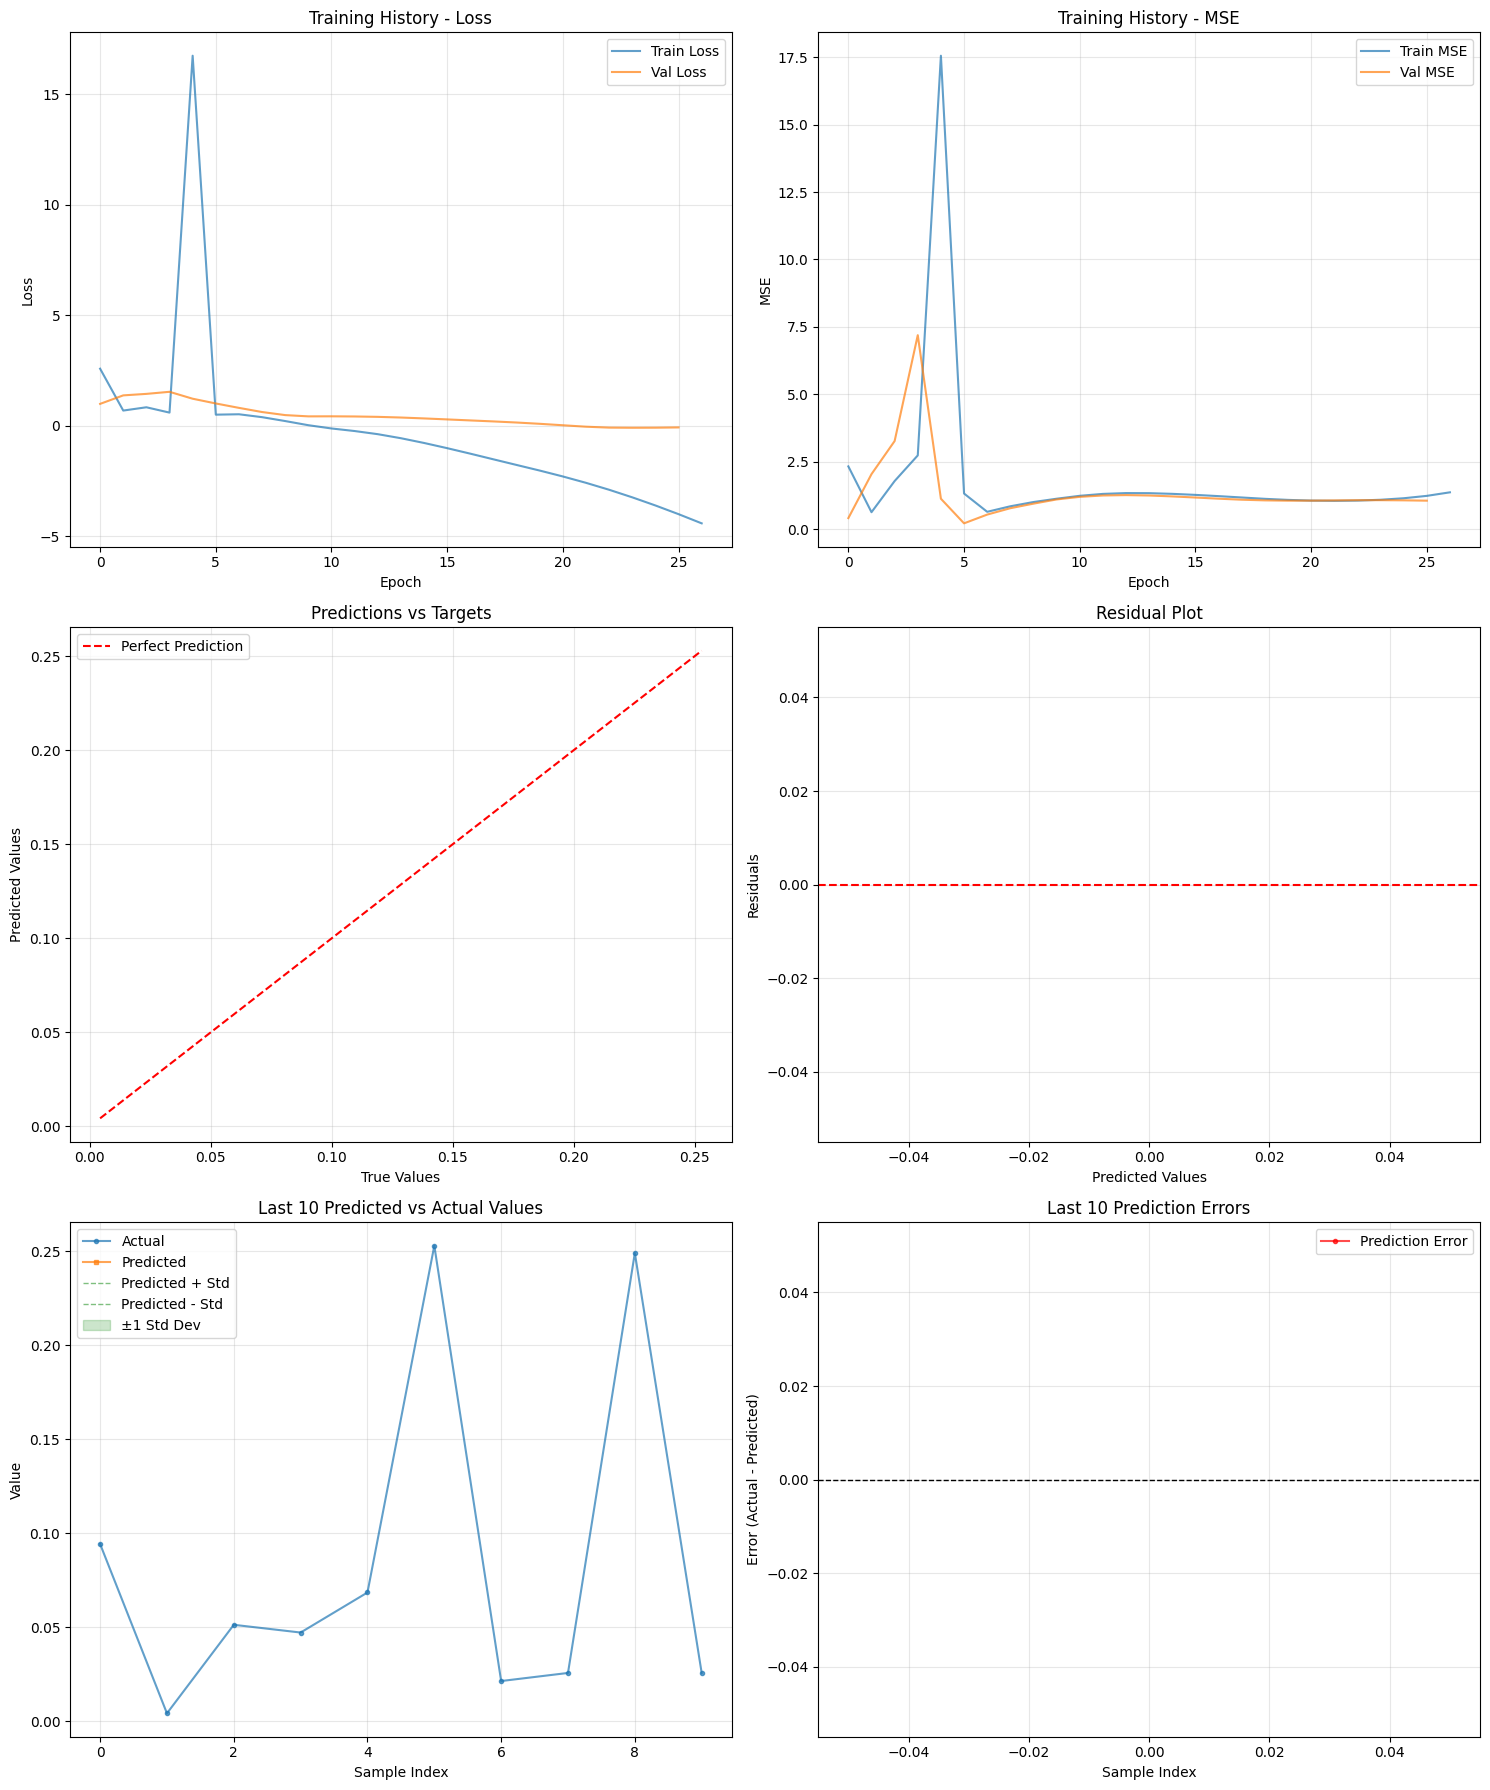

In [ ]:
# Plot results
plot_results(history, predictions, targets, variances=variances, save_path=PLOT_PATH)


## Save Model


In [ ]:
# Save model (this is the best model, loaded at end of training)
best_model_info = history.get('best_model_info', {})
best_epoch = best_model_info.get('best_epoch', NUM_EPOCHS)
best_val_loss = best_model_info.get('best_val_loss', history['val_loss'][-1] if history['val_loss'] else 0.0)

torch.save({
    'model_state_dict': model.state_dict(),
    'scaler': scaler,
    'feature_names': feature_names,
    'input_dim': input_dim,
    'hidden_dims': HIDDEN_DIMS,
    'best_epoch': best_epoch,
    'best_val_loss': best_val_loss
}, MODEL_PATH)

print(f"\nModel saved to {MODEL_PATH} (Best model from epoch {best_epoch}, Val Loss: {best_val_loss:.6f})")



Model saved to /home/wiseguy/dev/future_prices/futures_model.pt (Best model from epoch 24, Val Loss: -0.080834)


## Save Training Results


In [ ]:
# Save training results
config = {
    'target_col': TARGET_COL,
    'batch_size': BATCH_SIZE,
    'num_epochs': NUM_EPOCHS,
    'learning_rate': LEARNING_RATE,
    'optimize_mean_only_steps': OPTIMIZE_MEAN_ONLY_STEPS,
    'hidden_dims': HIDDEN_DIMS,
    'device': device
}

save_training_results(
    config=config,
    model=model,
    history=history,
    metrics=metrics,
    input_dim=input_dim,
    num_features=len(feature_names),
    train_size=len(X_train),
    test_size=len(X_test),
    results_path=RESULTS_PATH
)

print(f"Training results saved to {RESULTS_PATH}")


Training results saved to /home/wiseguy/dev/future_prices/training_results.txt
